In [1]:
# make sure to choose the python_course environment

# import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\stuco\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: xlabel='job_title_short'>

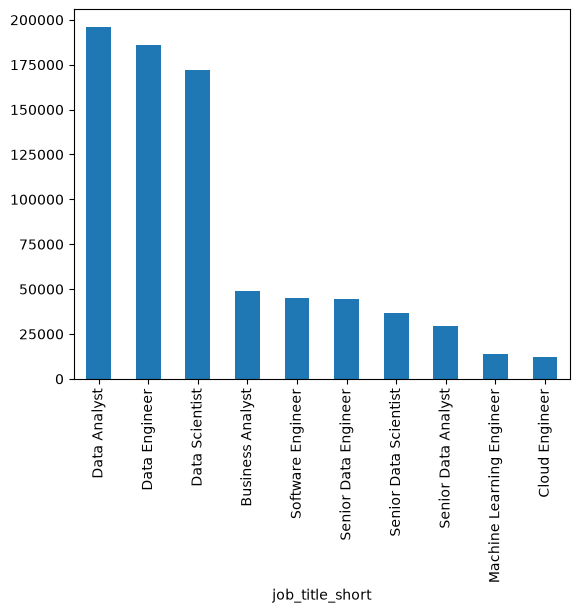

In [ ]:
# we're going to use matplotlib to compare charts

fig,ax = plt.subplots() # just to check

df['job_title_short'].value_counts().plot(kind="bar", ax=ax)

In [5]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

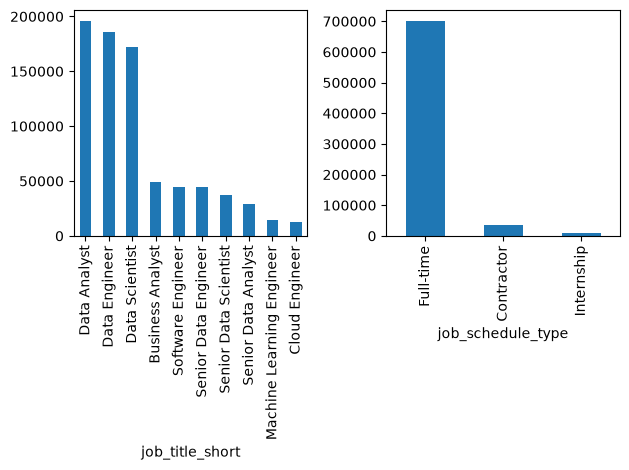

In [13]:
fig, ax = plt.subplots(1, 2)
# fig is the entire plot, ax is each visual we make

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind="bar", ax=ax[1])

# we'll get an error unless we specify ax for whatever index we're using
# for ax=ax, the indexes we'll use will be the columns declared above, job_title_short is 0, schedule type is 1, or vice versa

# the visual looks messy, so we'll use tight layout to sort it out

fig.tight_layout()

In [ ]:
# get the job skills df we made in explode exercise and the steps we took to make it

df_exploded = df.explode('job_skills')
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()
df_skills_count = skills_count.reset_index(name='skill_count') # we renamed the index "0" to skill_count
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [ ]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

# we're making a list to loop through titles and plot them individually on a figure in next step

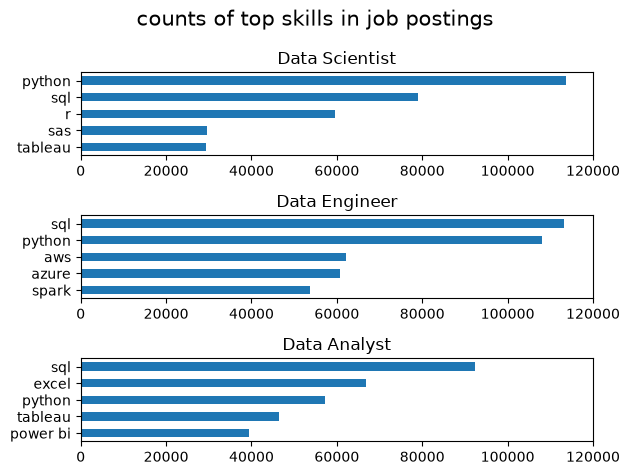

In [35]:
fig, ax = plt.subplots(3, 1) # (columns, rows)

for i, job_title in enumerate(job_titles): # enumerate outputs the indexes and values
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind="barh", x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 120000) # this counts the limits on the x axis so all charts will line up properly

# putting quotes around variables here can mess it up, watch out

fig.suptitle("counts of top skills in job postings", fontsize = 15) # do this before calling tight_layout
fig.tight_layout() 
